# Poster tables and figures

**Goal:** aggregate metrics and produce figures for the final poster.

In [2]:
%pip install -r ../requirements.txt


[notice] A new release of pip is available: 25.2 -> 26.1
[notice] To update, run: pip3.12 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [3]:
from pathlib import Path
import os
import sys

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

os.chdir(PROJECT_ROOT)
sys.path.insert(0, str(PROJECT_ROOT))

print("Project root:", PROJECT_ROOT)

Project root: /Users/polinakorobeinikova/IU/NLP/case-study/case-study-rag-factual-consistency


In [4]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

from src.config import METRICS_DIR, PLOTS_DIR, INDEX_DIR, PREDICTIONS_DIR
from src.analysis_utils import load_json

pd.set_option("display.max_colwidth", 160)
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

In [17]:
def save_fig(name: str):
    path = PLOTS_DIR / name
    plt.tight_layout()
    plt.savefig(path, dpi=220, bbox_inches="tight")
    plt.show()
    print("Saved:", path)

In [14]:
def load_json_if_exists(path: Path):
    if path.exists():
        with open(path, "r") as f:
            return json.load(f)
    return None

metric_files = {
    "Parametric-only": "parametric_metrics.json",
    "Vanilla RAG": "vanilla_rag_metrics.json",
    "Advanced RAG": "advanced_rag_hybrid_rerank_metrics.json",
}

rows = []

for display_name, filename in metric_files.items():
    metric = load_json_if_exists(METRICS_DIR / filename)

    if metric is None:
        print("Missing:", filename)
        continue

    row = dict(metric)
    row["display_system"] = display_name
    rows.append(row)

metrics_df = pd.DataFrame(rows)

# Ensure correct order.
order = ["Parametric-only", "Vanilla RAG", "Advanced RAG"]
metrics_df["display_system"] = pd.Categorical(
    metrics_df["display_system"],
    categories=order,
    ordered=True,
)
metrics_df = metrics_df.sort_values("display_system").reset_index(drop=True)

display(metrics_df)

metrics_df.to_csv(METRICS_DIR / "main_metrics_table_full.csv", index=False)

,system,exact_match,token_f1,contains_answer,n,answer_loss_mean,answer_loss_median,answer_loss_p90,answer_loss_p95,answer_loss_max,...,best_rerank_score_mean,best_rerank_score_median,best_rerank_score_p90,best_rerank_score_p95,best_rerank_score_max,generator_model,embedding_model,reranker_model,quality_gate_enabled,rerank_gate_threshold
0,parametric_only,0.0255,0.086888,0.1455,2000,3.945451,3.389435,7.731720,9.029060,18.314398,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,vanilla_rag_dense_top5,0.1060,0.184893,0.2550,2000,3.245940,2.517337,7.283772,9.059860,16.932407,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,advanced_rag_hybrid_rerank,0.1360,0.235866,0.3145,2000,2.666157,1.678559,6.414990,8.368244,16.151756,...,5.523036,5.664521,8.277368,8.885648,11.240532,Qwen/Qwen2.5-0.5B-Instruct,sentence-transformers/all-MiniLM-L6-v2,cross-encoder/ms-marco-MiniLM-L-6-v2,False,NaN


In [15]:
main_table = metrics_df[
    [
        "display_system",
        "n",
        "exact_match",
        "token_f1",
        "contains_answer",
        "answer_loss_mean",
        "answer_ppl_median",
        "total_latency_sec_mean",
    ]
].copy()

main_table = main_table.rename(
    columns={
        "display_system": "System",
        "n": "N",
        "exact_match": "Exact Match",
        "token_f1": "Token F1",
        "contains_answer": "Contains Answer",
        "answer_loss_mean": "Mean Answer Loss",
        "answer_ppl_median": "Median PPL",
        "total_latency_sec_mean": "Total Latency, sec",
    }
)

display(main_table)

main_table.to_csv(METRICS_DIR / "main_comparison_table.csv", index=False)

,System,N,Exact Match,Token F1,Contains Answer,Mean Answer Loss,Median PPL,"Total Latency, sec"
0,Parametric-only,2000,0.0255,0.086888,0.1455,3.945451,29.649291,2.110956
1,Vanilla RAG,2000,0.1060,0.184893,0.2550,3.245940,12.395587,2.768625
2,Advanced RAG,2000,0.1360,0.235866,0.3145,2.666157,5.357832,3.524217


In [16]:
poster_table = main_table.copy()

for col in ["Exact Match", "Token F1", "Contains Answer"]:
    poster_table[col] = poster_table[col].map(lambda x: f"{100 * x:.1f}%")

for col in ["Mean Answer Loss", "Median PPL", "Total Latency, sec"]:
    poster_table[col] = poster_table[col].map(lambda x: f"{x:.2f}")

display(poster_table)

poster_table.to_csv(METRICS_DIR / "poster_main_comparison_table.csv", index=False)

,System,N,Exact Match,Token F1,Contains Answer,Mean Answer Loss,Median PPL,"Total Latency, sec"
0,Parametric-only,2000,2.5%,8.7%,14.5%,3.95,29.65,2.11
1,Vanilla RAG,2000,10.6%,18.5%,25.5%,3.25,12.40,2.77
2,Advanced RAG,2000,13.6%,23.6%,31.4%,2.67,5.36,3.52



## Plot 1: answer quality


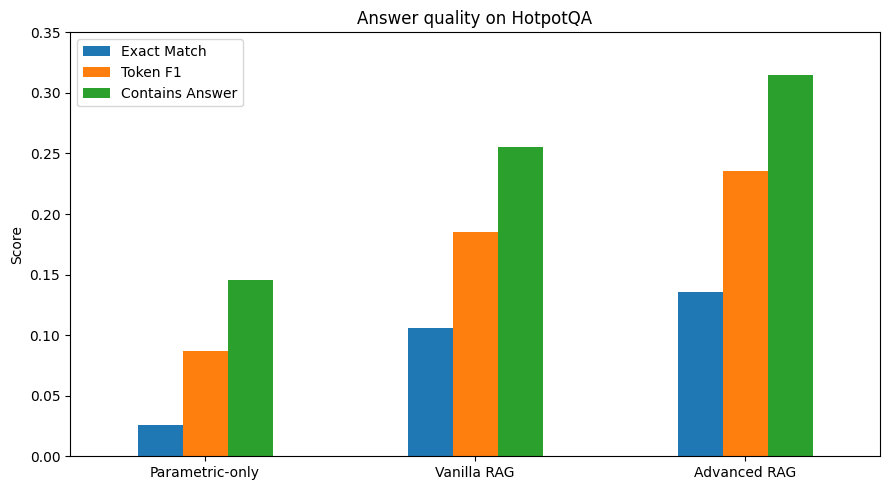

Saved: /Users/polinakorobeinikova/IU/NLP/case-study/case-study-rag-factual-consistency/results/plots/main_answer_quality.png


In [18]:
plot_df = metrics_df.set_index("display_system")[
    ["exact_match", "token_f1", "contains_answer"]
].copy()

plot_df = plot_df.rename(
    columns={
        "exact_match": "Exact Match",
        "token_f1": "Token F1",
        "contains_answer": "Contains Answer",
    }
)

ax = plot_df.plot(kind="bar", figsize=(9, 5))
ax.set_title("Answer quality on HotpotQA")
ax.set_xlabel("")
ax.set_ylabel("Score")
ax.set_ylim(0, 0.35)
ax.legend(loc="upper left")
plt.xticks(rotation=0)
save_fig("main_answer_quality.png")

# Plot 2: mean answer loss

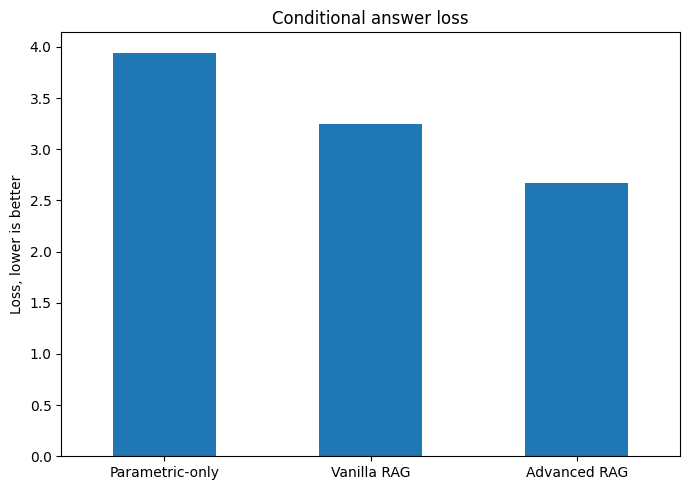

Saved: /Users/polinakorobeinikova/IU/NLP/case-study/case-study-rag-factual-consistency/results/plots/main_answer_loss.png


In [19]:
plot_df = metrics_df.set_index("display_system")[["answer_loss_mean"]].copy()
plot_df = plot_df.rename(columns={"answer_loss_mean": "Mean Answer Loss"})

ax = plot_df.plot(kind="bar", figsize=(7, 5), legend=False)
ax.set_title("Conditional answer loss")
ax.set_xlabel("")
ax.set_ylabel("Loss, lower is better")
plt.xticks(rotation=0)
save_fig("main_answer_loss.png")


## Plot 3: median perplexity


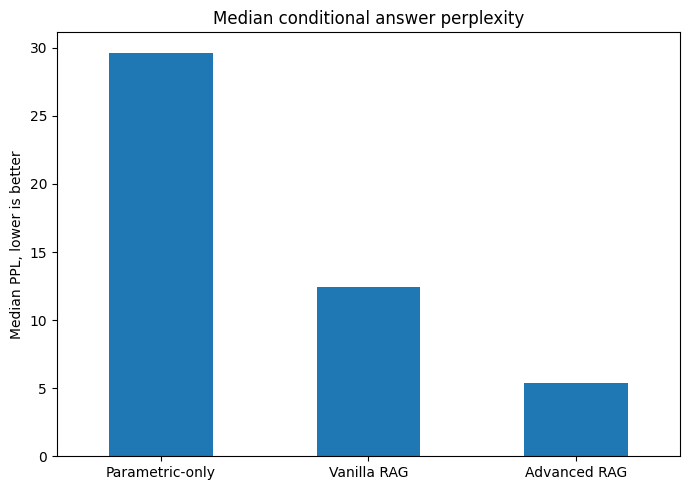

Saved: /Users/polinakorobeinikova/IU/NLP/case-study/case-study-rag-factual-consistency/results/plots/main_median_ppl.png


In [20]:
plot_df = metrics_df.set_index("display_system")[["answer_ppl_median"]].copy()
plot_df = plot_df.rename(columns={"answer_ppl_median": "Median PPL"})

ax = plot_df.plot(kind="bar", figsize=(7, 5), legend=False)
ax.set_title("Median conditional answer perplexity")
ax.set_xlabel("")
ax.set_ylabel("Median PPL, lower is better")
plt.xticks(rotation=0)
save_fig("main_median_ppl.png")


## Plot 4: latency


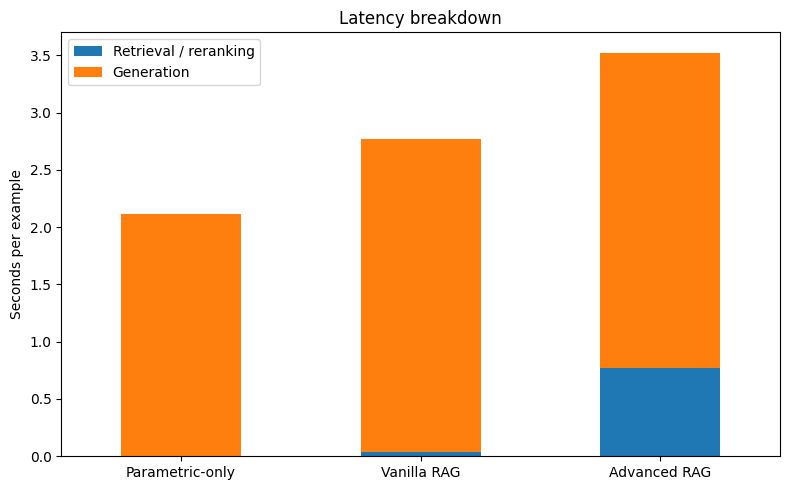

Saved: /Users/polinakorobeinikova/IU/NLP/case-study/case-study-rag-factual-consistency/results/plots/latency_breakdown.png


In [21]:
lat_df = metrics_df.set_index("display_system")[
    ["retrieval_latency_sec_mean", "generation_latency_sec_mean"]
].copy()

lat_df = lat_df.fillna(0.0)

lat_df = lat_df.rename(
    columns={
        "retrieval_latency_sec_mean": "Retrieval / reranking",
        "generation_latency_sec_mean": "Generation",
    }
)

ax = lat_df.plot(kind="bar", stacked=True, figsize=(8, 5))
ax.set_title("Latency breakdown")
ax.set_xlabel("")
ax.set_ylabel("Seconds per example")
plt.xticks(rotation=0)
save_fig("latency_breakdown.png")


## Plot 5: retrieval quality


In [33]:
robust_summary = pd.read_csv(robust_path)

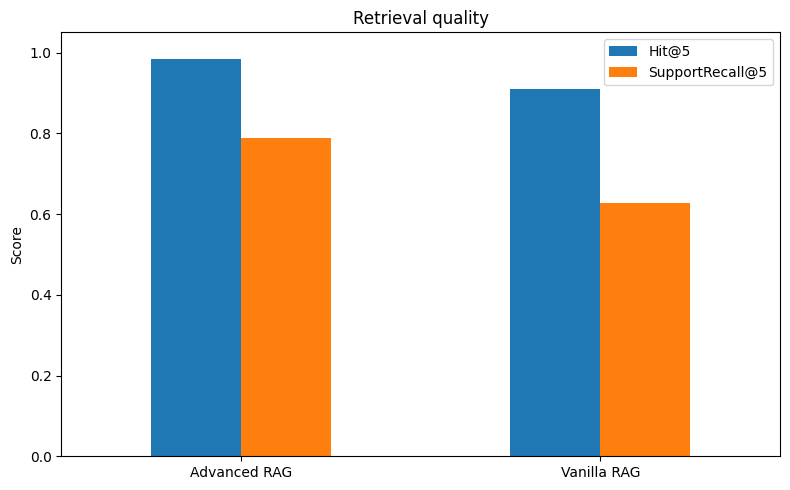

In [34]:
fresh_retrieval = robust_summary[robust_summary["condition"] == "fresh"].copy()

name_map = {
    "vanilla_rag_dense": "Vanilla RAG",
    "advanced_rag_hybrid_rerank": "Advanced RAG",
}

fresh_retrieval["display_system"] = (
    fresh_retrieval["system"].map(name_map).fillna(fresh_retrieval["system"])
)

retrieval_plot = fresh_retrieval[
    [
        "display_system",
        "retrieval_hit_at_5_mean",
        "support_recall_at_5_mean",
    ]
].copy()

retrieval_plot = retrieval_plot.rename(
    columns={
        "display_system": "System",
        "retrieval_hit_at_5_mean": "Hit@5",
        "support_recall_at_5_mean": "SupportRecall@5",
    }
)

retrieval_plot = retrieval_plot.set_index("System")

ax = retrieval_plot.plot(kind="bar", figsize=(8, 5))
ax.set_title("Retrieval quality")
ax.set_xlabel("")
ax.set_ylabel("Score")
ax.set_ylim(0, 1.05)
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(PLOTS_DIR / "retrieval_quality_fixed.png", dpi=220, bbox_inches="tight")
plt.show()


## Robustness summary


In [23]:
robust_path = METRICS_DIR / "robustness_summary.csv"

if robust_path.exists():
    robust_summary = pd.read_csv(robust_path)

    # Normalize names for poster readability.
    name_map = {
        "vanilla_rag_dense": "Vanilla RAG",
        "advanced_rag_hybrid_rerank": "Advanced RAG",
    }

    robust_summary["display_system"] = robust_summary["system"].map(name_map).fillna(robust_summary["system"])

    condition_order = [
        "fresh",
        "noisy_context",
        "conflicting_context",
        "missing_evidence",
    ]

    robust_summary["condition"] = pd.Categorical(
        robust_summary["condition"],
        categories=condition_order,
        ordered=True,
    )

    robust_summary = robust_summary.sort_values(["display_system", "condition"]).reset_index(drop=True)

    display(robust_summary)

    robust_summary.to_csv(METRICS_DIR / "robustness_summary_for_poster.csv", index=False)
else:
    print("Missing robustness_summary.csv. Run notebook 06 first.")

,system,condition,exact_match,token_f1,contains_answer,n,answer_loss_mean,answer_loss_median,answer_loss_p90,answer_loss_p95,...,generation_latency_sec_median,generation_latency_sec_p90,generation_latency_sec_p95,generation_latency_sec_max,total_latency_sec_mean,total_latency_sec_median,total_latency_sec_p90,total_latency_sec_p95,total_latency_sec_max,display_system
0,advanced_rag_hybrid_rerank,fresh,0.1360,0.235866,0.3145,2000,2.666157,1.678559,6.414990,8.368244,...,2.412807,3.234580,3.637258,6.508129,3.308101,3.028148,4.398575,4.984727,8.116201,Advanced RAG
1,advanced_rag_hybrid_rerank,noisy_context,0.1180,0.209757,0.2855,2000,2.856370,1.893985,6.667561,8.666060,...,2.437743,3.259087,3.561442,13.485506,3.068125,2.919789,3.801550,4.119870,14.006956,Advanced RAG
2,advanced_rag_hybrid_rerank,conflicting_context,0.0645,0.132087,0.1375,2000,4.026764,3.511364,8.355150,9.954699,...,2.422021,2.975802,3.339010,13.106098,3.009535,2.882536,3.505620,3.888642,13.369888,Advanced RAG
3,advanced_rag_hybrid_rerank,missing_evidence,0.0615,0.115298,0.1455,2000,4.267008,3.701300,8.530205,10.304334,...,2.692188,4.070971,4.383382,10.169812,3.515234,3.212772,4.666336,5.034014,10.597976,Advanced RAG
4,vanilla_rag_dense,fresh,0.1060,0.184893,0.2550,2000,3.245940,2.517337,7.283772,9.059860,...,2.532079,3.156729,3.458903,14.248625,2.702310,2.568891,3.207044,3.513118,14.361630,Vanilla RAG
5,vanilla_rag_dense,noisy_context,0.0940,0.164563,0.2270,2000,3.527675,2.814115,7.592297,9.554199,...,2.782755,3.952624,5.142018,31.239624,3.306823,2.914005,4.109223,5.418776,31.401608,Vanilla RAG
6,vanilla_rag_dense,conflicting_context,0.0570,0.114028,0.1255,2000,4.288275,3.748987,8.438060,10.093726,...,2.594815,3.314122,3.694449,17.883134,2.817813,2.649321,3.391314,3.759585,17.900630,Vanilla RAG
7,vanilla_rag_dense,missing_evidence,0.0500,0.098896,0.1225,2000,4.499603,3.939072,8.764830,10.535580,...,2.624837,3.396834,3.911420,23.401413,2.860821,2.665022,3.451040,3.971516,23.455936,Vanilla RAG


## Robustess token f1 plot

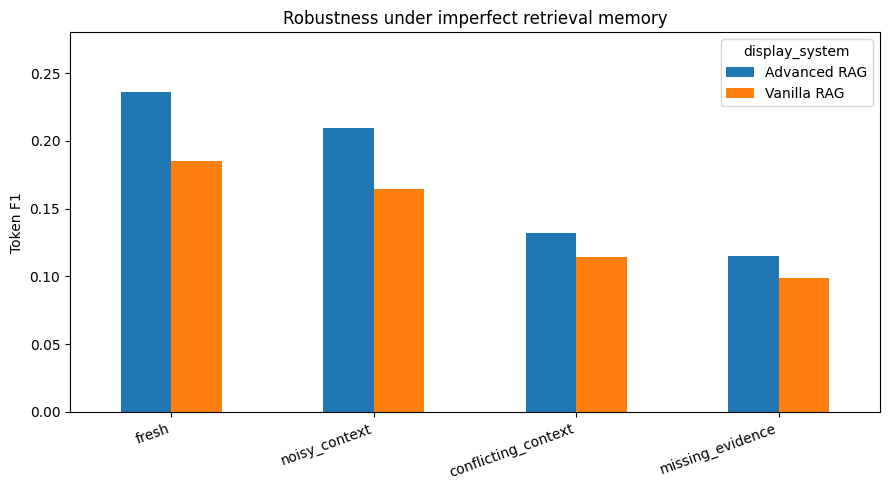

Saved: /Users/polinakorobeinikova/IU/NLP/case-study/case-study-rag-factual-consistency/results/plots/robustness_token_f1.png


In [24]:
if robust_path.exists():
    pivot = robust_summary.pivot(
        index="condition",
        columns="display_system",
        values="token_f1",
    )

    ax = pivot.plot(kind="bar", figsize=(9, 5))
    ax.set_title("Robustness under imperfect retrieval memory")
    ax.set_xlabel("")
    ax.set_ylabel("Token F1")
    ax.set_ylim(0, 0.28)
    plt.xticks(rotation=20, ha="right")
    save_fig("robustness_token_f1.png")

## Robustness answer loss plot

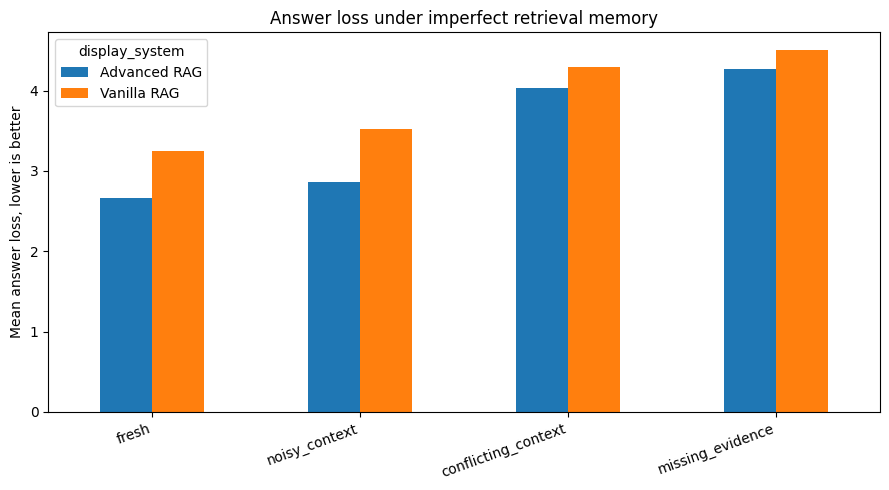

Saved: /Users/polinakorobeinikova/IU/NLP/case-study/case-study-rag-factual-consistency/results/plots/robustness_answer_loss.png


In [25]:
if robust_path.exists():
    pivot = robust_summary.pivot(
        index="condition",
        columns="display_system",
        values="answer_loss_mean",
    )

    ax = pivot.plot(kind="bar", figsize=(9, 5))
    ax.set_title("Answer loss under imperfect retrieval memory")
    ax.set_xlabel("")
    ax.set_ylabel("Mean answer loss, lower is better")
    plt.xticks(rotation=20, ha="right")
    save_fig("robustness_answer_loss.png")

## Robustess deltas relative to fresh

In [26]:
if robust_path.exists():
    delta_rows = []

    for system_name, group in robust_summary.groupby("display_system"):
        fresh_row = group[group["condition"] == "fresh"]

        if fresh_row.empty:
            continue

        fresh_row = fresh_row.iloc[0]

        for _, row in group.iterrows():
            delta_rows.append(
                {
                    "System": system_name,
                    "Condition": row["condition"],
                    "Token F1": row["token_f1"],
                    "Token F1 delta vs fresh": row["token_f1"] - fresh_row["token_f1"],
                    "Exact Match": row["exact_match"],
                    "Exact Match delta vs fresh": row["exact_match"] - fresh_row["exact_match"],
                    "Mean Answer Loss": row["answer_loss_mean"],
                    "Loss delta vs fresh": row["answer_loss_mean"] - fresh_row["answer_loss_mean"],
                }
            )

    robust_deltas = pd.DataFrame(delta_rows)
    display(robust_deltas)

    robust_deltas.to_csv(METRICS_DIR / "robustness_deltas_vs_fresh.csv", index=False)

,System,Condition,Token F1,Token F1 delta vs fresh,Exact Match,Exact Match delta vs fresh,Mean Answer Loss,Loss delta vs fresh
0,Advanced RAG,fresh,0.235866,0.000000,0.1360,0.0000,2.666157,0.000000
1,Advanced RAG,noisy_context,0.209757,-0.026109,0.1180,-0.0180,2.856370,0.190212
2,Advanced RAG,conflicting_context,0.132087,-0.103780,0.0645,-0.0715,4.026764,1.360607
3,Advanced RAG,missing_evidence,0.115298,-0.120568,0.0615,-0.0745,4.267008,1.600851
4,Vanilla RAG,fresh,0.184893,0.000000,0.1060,0.0000,3.245940,0.000000
5,Vanilla RAG,noisy_context,0.164563,-0.020330,0.0940,-0.0120,3.527675,0.281735
6,Vanilla RAG,conflicting_context,0.114028,-0.070865,0.0570,-0.0490,4.288275,1.042335
7,Vanilla RAG,missing_evidence,0.098896,-0.085997,0.0500,-0.0560,4.499603,1.253663



## Memory table


In [27]:
def save_json(path: Path, obj: dict):
    path.parent.mkdir(parents=True, exist_ok=True)
    with open(path, "w") as f:
        json.dump(obj, f, indent=2)

In [28]:
memory_fallback = {
    "generator_model": "Qwen/Qwen2.5-0.5B-Instruct",
    "generator_model_size_mb_estimate": 1884.58544921875,
    "dense_faiss_index_mb": 72.91117572784424,
    "dense_embeddings_mb": 72.9112548828125,
    "bm25_index_mb": 56.24495029449463,
    "all_index_files_mb": 212.5265769958496,
    "n_documents": 49774,
}

memory_path = METRICS_DIR / "memory_summary.json"

if memory_path.exists():
    memory_summary = load_json_if_exists(memory_path)
else:
    memory_summary = memory_fallback
    save_json(memory_path, memory_summary)

memory_df = pd.DataFrame(
    [
        {"Item": "Generator model", "Size MB": memory_summary["generator_model_size_mb_estimate"]},
        {"Item": "FAISS dense index", "Size MB": memory_summary["dense_faiss_index_mb"]},
        {"Item": "Stored dense embeddings", "Size MB": memory_summary["dense_embeddings_mb"]},
        {"Item": "BM25 index", "Size MB": memory_summary["bm25_index_mb"]},
        {"Item": "All index files", "Size MB": memory_summary["all_index_files_mb"]},
    ]
)

display(memory_df)

memory_df.to_csv(METRICS_DIR / "memory_table.csv", index=False)

,Item,Size MB
0,Generator model,1884.585449
1,FAISS dense index,72.911176
2,Stored dense embeddings,72.911255
3,BM25 index,56.244950
4,All index files,212.526577


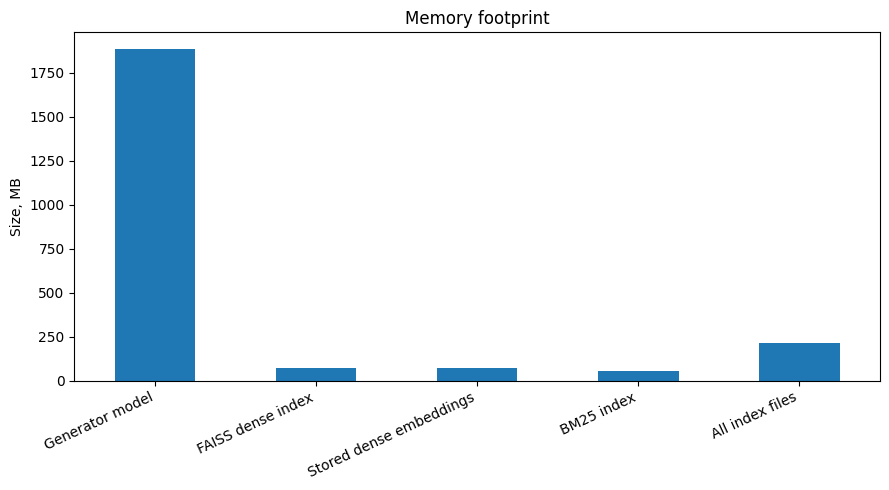

Saved: /Users/polinakorobeinikova/IU/NLP/case-study/case-study-rag-factual-consistency/results/plots/memory_footprint.png


In [29]:
plot_df = memory_df.set_index("Item")[["Size MB"]]

ax = plot_df.plot(kind="bar", figsize=(9, 5), legend=False)
ax.set_title("Memory footprint")
ax.set_xlabel("")
ax.set_ylabel("Size, MB")
plt.xticks(rotation=25, ha="right")
save_fig("memory_footprint.png")

## Quality gate ablation

In [30]:
gate_ablation = pd.DataFrame(
    [
        {
            "System": "Advanced RAG with naive quality gate",
            "N": 2000,
            "Exact Match": 0.0595,
            "Token F1": 0.11182675100448695,
            "Contains Answer": 0.173,
            "Quality gated rate": 0.517,
            "Gate threshold": 5.772075653076172,
        },
        {
            "System": "Advanced RAG without active gate",
            "N": 2000,
            "Exact Match": 0.136,
            "Token F1": 0.23586640829852712,
            "Contains Answer": 0.3145,
            "Quality gated rate": 0.0,
            "Gate threshold": None,
        },
    ]
)

display(gate_ablation)

gate_ablation.to_csv(METRICS_DIR / "quality_gate_ablation.csv", index=False)

,System,N,Exact Match,Token F1,Contains Answer,Quality gated rate,Gate threshold
0,Advanced RAG with naive quality gate,2000,0.0595,0.111827,0.1730,0.517,5.772076
1,Advanced RAG without active gate,2000,0.1360,0.235866,0.3145,0.000,NaN


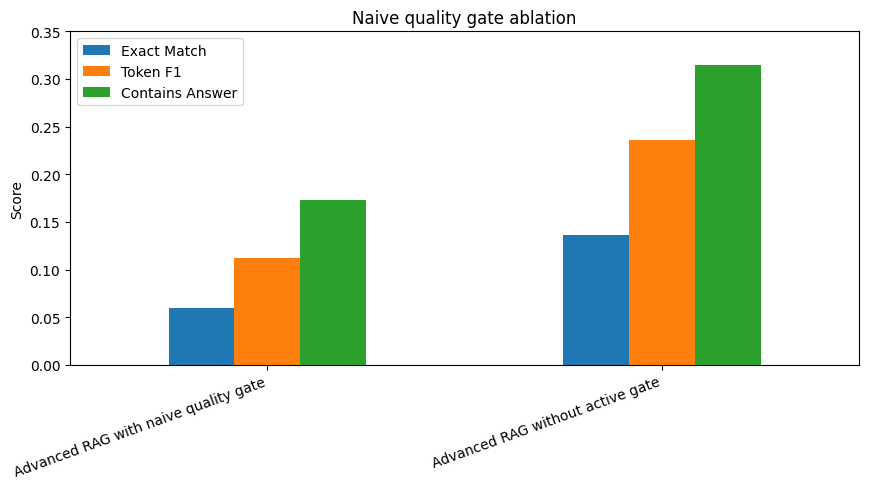

Saved: /Users/polinakorobeinikova/IU/NLP/case-study/case-study-rag-factual-consistency/results/plots/quality_gate_ablation.png


In [31]:
plot_df = gate_ablation.set_index("System")[
    ["Exact Match", "Token F1", "Contains Answer"]
]

ax = plot_df.plot(kind="bar", figsize=(9, 5))
ax.set_title("Naive quality gate ablation")
ax.set_xlabel("")
ax.set_ylabel("Score")
ax.set_ylim(0, 0.35)
plt.xticks(rotation=20, ha="right")
save_fig("quality_gate_ablation.png")